<a href="https://colab.research.google.com/github/araefinn/MIS444/blob/araefinn-patch-1/Rupam_Arefin_MIS444_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predictive analysis on Drug prescription**

> **Data Overview**



In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
data = pd.read_csv('drug200.csv')

print("First few rows of the dataset:")
print(data.head())

print("\nInformation about the dataset:")
print(data.info())

Saving drug200.csv to drug200.csv
First few rows of the dataset:
   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None


In [ ]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000




> **Data understanding**




Data type and frequency table for qualitative features:

Feature: Sex
Frequency table:
M: Count=104, Percentage=52.00%
F: Count=96, Percentage=48.00%

Feature: BP
Frequency table:
HIGH: Count=77, Percentage=38.50%
LOW: Count=64, Percentage=32.00%
NORMAL: Count=59, Percentage=29.50%

Feature: Cholesterol
Frequency table:
HIGH: Count=103, Percentage=51.50%
NORMAL: Count=97, Percentage=48.50%

Feature: Drug
Frequency table:
drugY: Count=91, Percentage=45.50%
drugX: Count=54, Percentage=27.00%
drugA: Count=23, Percentage=11.50%
drugC: Count=16, Percentage=8.00%
drugB: Count=16, Percentage=8.00%

Unique values in categorical columns:
Sex: ['F' 'M']
BP: ['HIGH' 'LOW' 'NORMAL']
Cholesterol: ['HIGH' 'NORMAL']
Drug: ['drugY' 'drugC' 'drugX' 'drugA' 'drugB']


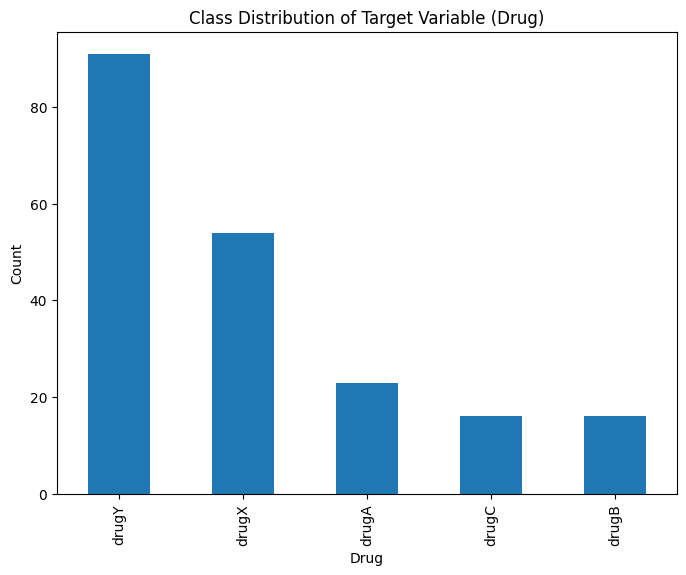

In [6]:
data = pd.read_csv('drug200.csv')

def print_frequency_table(column):
    print("\nFeature:", column)
    print("Frequency table:")
    frequency_table = data[column].value_counts()
    total_samples = len(data)
    for category, count in frequency_table.items():
        percentage = (count / total_samples) * 100
        print(f"{category}: Count={count}, Percentage={percentage:.2f}%")

print("\nData type and frequency table for qualitative features:")
for column in data.select_dtypes(include=['object']):
    print_frequency_table(column)

print("\nUnique values in categorical columns:")
for column in data.select_dtypes(include=['object']):
    print(f"{column}: {data[column].unique()}")

import matplotlib.pyplot as plt

class_counts = data['Drug'].value_counts()

plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution of Target Variable (Drug)')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.show()

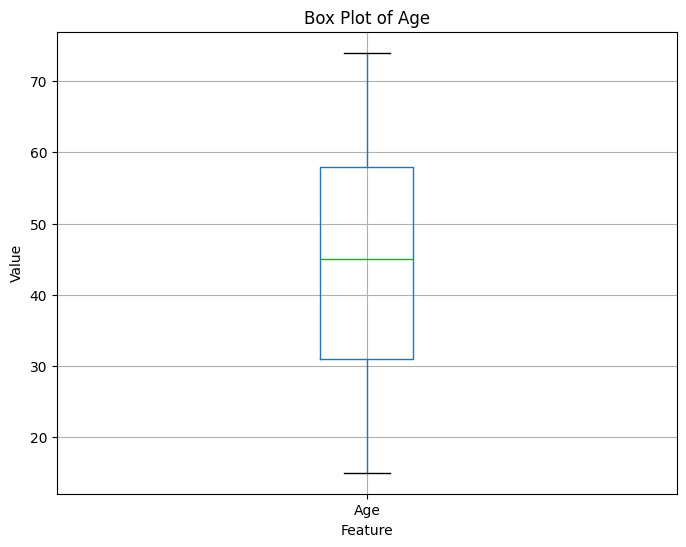

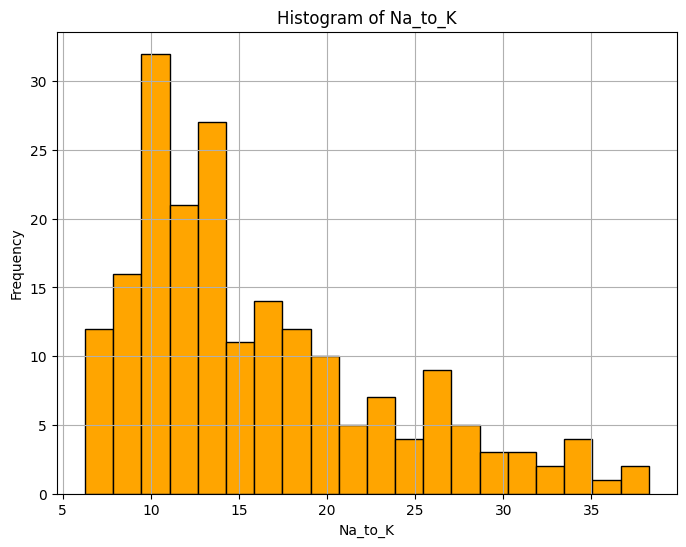

In [7]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('drug200.csv')

data.boxplot(column=['Age'], figsize=(8, 6))
plt.title('Box Plot of Age')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(data['Na_to_K'], bins=20, color='orange', edgecolor='black')
plt.title('Histogram of Na_to_K')
plt.xlabel('Na_to_K')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

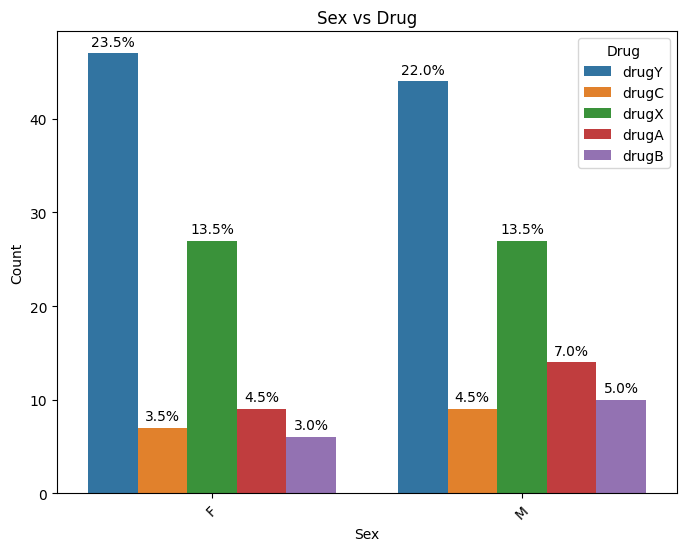

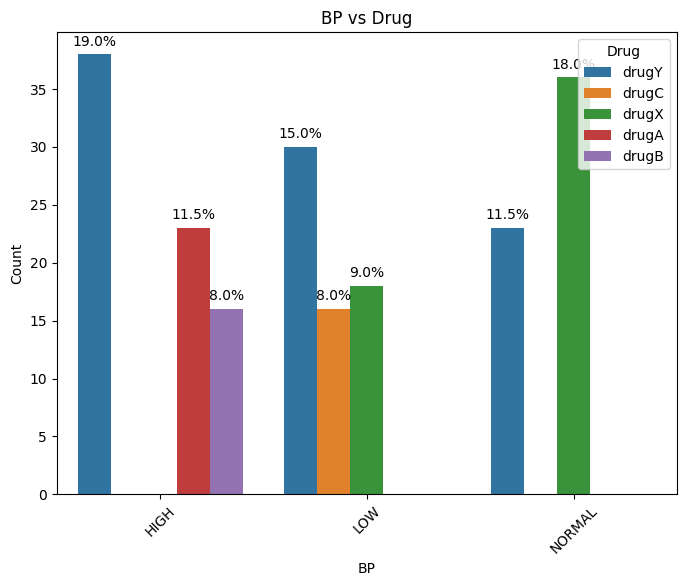

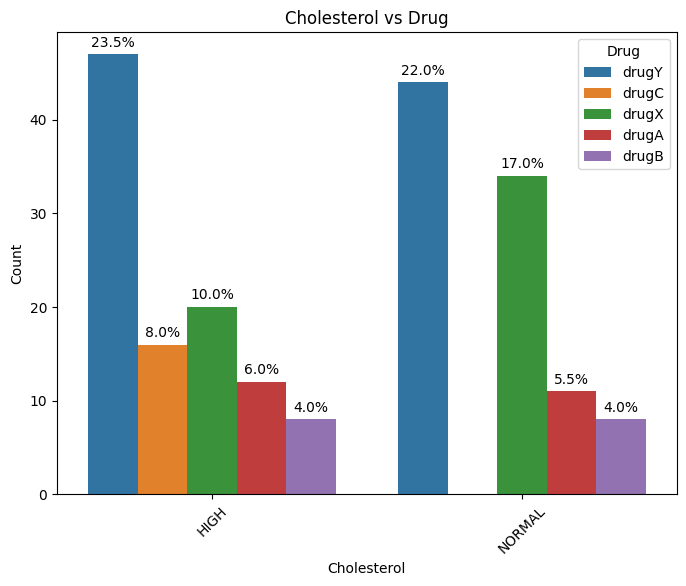

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_vs_target(feature):
    if data[feature].dtype == 'object':
        plt.figure(figsize=(8, 6))
        sns.countplot(x=feature, hue='Drug', data=data)
        plt.title(f'{feature} vs Drug')
        plt.xlabel(feature)
        plt.ylabel('Count')
        plt.legend(title='Drug', loc='upper right')
        plt.xticks(rotation=45)

        total_count_all = data.shape[0]
        for drug in data['Drug'].unique():
            total_count = data[data['Drug'] == drug].shape[0]
            for i, p in enumerate(plt.gca().patches):
                if p.get_height() > 0:
                    if i % len(data['Drug'].unique()) == data['Drug'].unique().tolist().index(drug):
                        plt.text(p.get_x() + p.get_width() / 2.,
                                 p.get_height() + 0.5,
                                 f'{p.get_height() / total_count_all * 100:.1f}%',
                                 ha='center', va='bottom')


for feature in data.columns[:-1]:
    plot_feature_vs_target(feature)

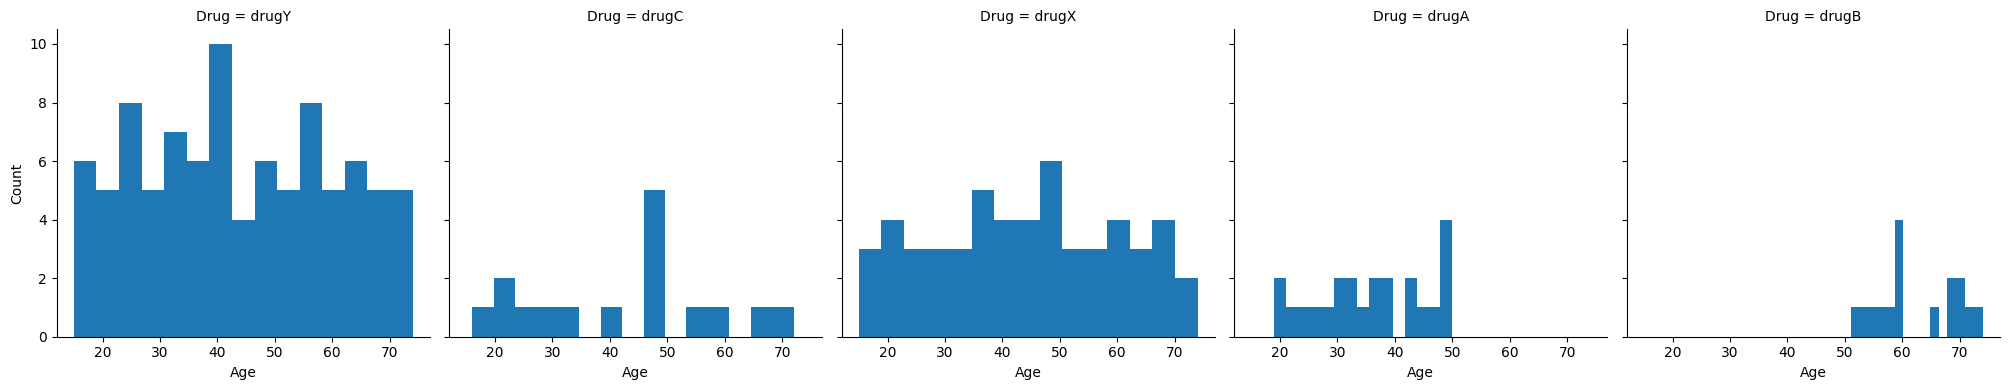

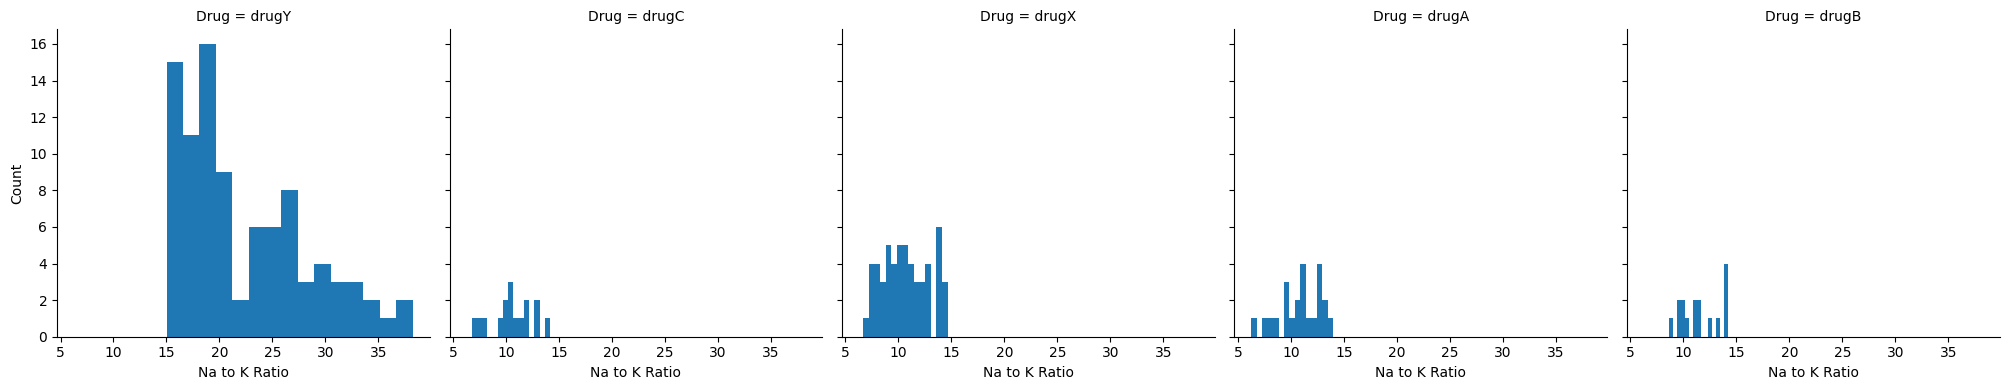

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('drug200.csv')


g = sns.FacetGrid(data, col='Drug', height=4)
g.map(plt.hist, 'Age', bins=15)
g.set_axis_labels('Age', 'Count')
g.set_titles('Drug = {col_name}')
plt.show()

g = sns.FacetGrid(data, col='Drug', height=4)
g.map(plt.hist, 'Na_to_K', bins=15)
g.set_axis_labels('Na to K Ratio', 'Count')
g.set_titles('Drug = {col_name}')
plt.show()

Columns in dataset: Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')


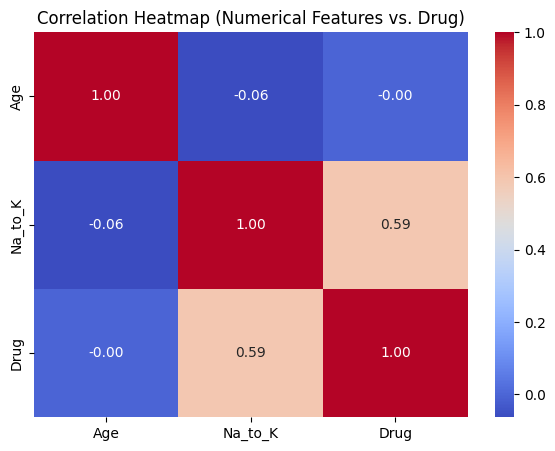

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


data.columns = data.columns.str.strip()


print("Columns in dataset:", data.columns)


numerical_features = ['Age', 'Na_to_K']


label_encoder = LabelEncoder()
data['Drug'] = label_encoder.fit_transform(data['Drug'])


correlation_matrix = data[numerical_features + ['Drug']].corr()


plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numerical Features vs. Drug)')
plt.show()


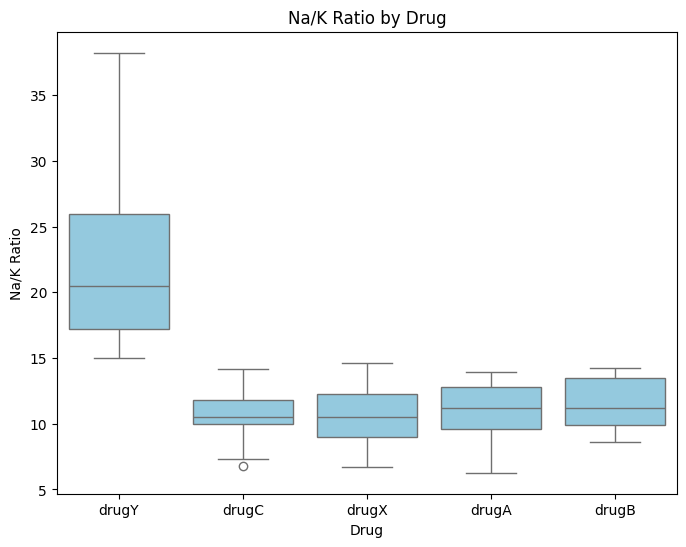

T-test: t-statistic = 18.607346469361048, p-value = 2.3831892842384878e-45


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


data['Na/K Ratio'] = data['Na_to_K']


class_names_full = {
    0: "drugA",
    1: "drugB",
    2: "drugC",
    3: "drugX",
    4: "drugY"
}


data['Drug'] = data['Drug'].map(class_names_full)


plt.figure(figsize=(8, 6))
sns.boxplot(x='Drug', y='Na/K Ratio', data=data, color='skyblue')
plt.title('Na/K Ratio by Drug')
plt.xlabel('Drug')
plt.ylabel('Na/K Ratio')
plt.show()

from scipy.stats import ttest_ind

drugY_ratio = data[data['Drug'] == 'drugY']['Na/K Ratio']
other_drugs_ratio = data[data['Drug'] != 'drugY']['Na/K Ratio']

t_statistic, p_value = ttest_ind(drugY_ratio, other_drugs_ratio)

print(f'T-test: t-statistic = {t_statistic}, p-value = {p_value}')

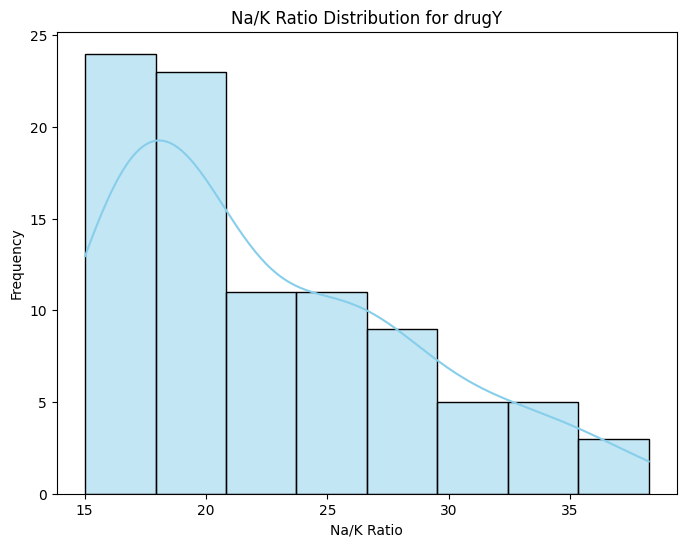

   Age Sex Blood Pressure Cholesterol  Na_to_K   Drug
0   23   F           HIGH        HIGH   25.355  drugY
1   47   M            LOW        HIGH   13.093  drugC
2   47   M            LOW        HIGH   10.114  drugC
3   28   F         NORMAL        HIGH    7.798  drugX
4   61   F            LOW        HIGH   18.043  drugY


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.simplefilter(action='ignore', category=FutureWarning)


data = pd.read_csv('drug200.csv')


data = data.rename(columns={'BP': 'Blood Pressure'})


drug_column = data.pop('Drug')
data['Drug'] = drug_column


drugY_data = data[data['Drug'] == 'drugY'].copy()


drugY_data['Na_to_K'] = drugY_data['Na_to_K'].replace([pd.NA, float('inf'), -float('inf')], pd.NA)


drugY_data = drugY_data.dropna(subset=['Na_to_K'])


plt.figure(figsize=(8, 6))
sns.histplot(drugY_data['Na_to_K'], kde=True, color='skyblue')
plt.title('Na/K Ratio Distribution for drugY')
plt.xlabel('Na/K Ratio')
plt.ylabel('Frequency')
plt.show()


print(data.head())


In [13]:
import pandas as pd
from scipy.stats import chi2_contingency

data = pd.read_csv('drug200.csv')


contingency_table = pd.crosstab(data['Drug'], data['Sex'])


chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square test statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Contingency Table:")
print(contingency_table)
print("Expected frequencies table:")
print(expected)

Chi-square test statistic: 2.119248418109203
p-value: 0.7138369773987128
Degrees of freedom: 4
Contingency Table:
Sex     F   M
Drug         
drugA   9  14
drugB   6  10
drugC   7   9
drugX  27  27
drugY  47  44
Expected frequencies table:
[[11.04 11.96]
 [ 7.68  8.32]
 [ 7.68  8.32]
 [25.92 28.08]
 [43.68 47.32]]


In [14]:
import pandas as pd
from scipy.stats import f_oneway, chi2_contingency


data.columns = data.columns.str.strip()


# 1. Numerical Features ANOVA

numerical_features = ['Age', 'Na_to_K']
anova_results = {}
for feature in numerical_features:
    groups = [group[feature].values for name, group in data.groupby('Drug')]
    f_stat, p_val = f_oneway(*groups)
    anova_results[feature] = p_val


# 2. Categorical Features Chi-square

categorical_features = ['Sex', 'BP', 'Cholesterol']
chi2_results = {}
for feature in categorical_features:
    contingency_table = pd.crosstab(data[feature], data['Drug'])
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results[feature] = p_val


summary = []

for feature, p_val in anova_results.items():
    summary.append({
        'Feature': feature,
        'Type': 'Numerical',
        'p-value': round(p_val, 4),
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

for feature, p_val in chi2_results.items():
    summary.append({
        'Feature': feature,
        'Type': 'Categorical',
        'p-value': round(p_val, 4),
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

summary_df = pd.DataFrame(summary)


print(summary_df)

       Feature         Type  p-value Significant
0          Age    Numerical   0.0000         Yes
1      Na_to_K    Numerical   0.0000         Yes
2          Sex  Categorical   0.7138          No
3           BP  Categorical   0.0000         Yes
4  Cholesterol  Categorical   0.0006         Yes




> **Data Preparation**



In [15]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

data = pd.read_csv('drug200.csv')


sex_classes = ['F', 'M']
bp_classes = ['LOW', 'NORMAL', 'HIGH']
cholesterol_classes = ['NORMAL', 'HIGH']
drug_classes = ['drugA', 'drugB', 'drugC', 'drugX', 'drugY']


ordinal_encoder = OrdinalEncoder(categories=[sex_classes, bp_classes, cholesterol_classes])
data[['Sex', 'BP', 'Cholesterol']] = ordinal_encoder.fit_transform(data[['Sex', 'BP', 'Cholesterol']])


label_encoder = LabelEncoder()
data['Drug'] = label_encoder.fit_transform(data['Drug'])


print(data.head())


   Age  Sex   BP  Cholesterol  Na_to_K  Drug
0   23  0.0  2.0          1.0   25.355     4
1   47  1.0  0.0          1.0   13.093     2
2   47  1.0  0.0          1.0   10.114     2
3   28  0.0  1.0          1.0    7.798     3
4   61  0.0  0.0          1.0   18.043     4


In [16]:
from sklearn.model_selection import train_test_split


X = data.drop('Drug', axis=1)  # Features (all columns except 'Drug')
y = data['Drug']  # Target variable ('Drug')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42, stratify=y)


print("Training set shape (X, y):", X_train.shape, y_train.shape)
print("Testing set shape (X, y):", X_test.shape, y_test.shape)

Training set shape (X, y): (130, 5) (130,)
Testing set shape (X, y): (70, 5) (70,)


In [17]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train[['Age', 'Na_to_K']] = scaler.fit_transform(X_train[['Age', 'Na_to_K']])
X_test[['Age', 'Na_to_K']] = scaler.transform(X_test[['Age', 'Na_to_K']])


print("Updated Training Data:")
print(X_train.head())

Updated Training Data:
          Age  Sex   BP  Cholesterol   Na_to_K
66  -1.004109  1.0  2.0          1.0 -0.453801
115  0.315024  1.0  2.0          1.0  0.343488
172 -0.404503  0.0  1.0          0.0  0.186640
98  -1.543754  1.0  2.0          0.0  2.885899
51   1.274393  1.0  1.0          0.0 -0.740819




> **Modeling**



In [33]:
from sklearn.tree import _tree
from sklearn.tree import DecisionTreeClassifier

def get_rules_iterative(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    stack = [(0, [], [])]

    while stack:
        node_id, conditions, classes = stack.pop()
        if tree_.feature[node_id] != _tree.TREE_UNDEFINED:
            name = feature_name[node_id]
            threshold = tree_.threshold[node_id]
            # Left child
            stack.append(
                (tree_.children_left[node_id],
                 conditions + [f"{name} <= {threshold:.2f}"],
                 classes)
            )
            # Right child
            stack.append(
                (tree_.children_right[node_id],
                 conditions + [f"{name} > {threshold:.2f}"],
                 classes)
            )
        else:
            value = tree_.value[node_id][0]
            class_id = value.argmax()
            paths.append(" AND ".join(conditions) + f" => {class_names[class_id]}")
    return paths

Decision Tree Model Rules:
Na_to_K > -0.15 => drugY
Na_to_K <= -0.15 AND BP > 1.50 AND Age > 0.37 => drugB
Na_to_K <= -0.15 AND BP > 1.50 AND Age <= 0.37 => drugA
Na_to_K <= -0.15 AND BP <= 1.50 AND BP > 0.50 => drugX
Na_to_K <= -0.15 AND BP <= 1.50 AND BP <= 0.50 AND Cholesterol > 0.50 => drugC
Na_to_K <= -0.15 AND BP <= 1.50 AND BP <= 0.50 AND Cholesterol <= 0.50 => drugX


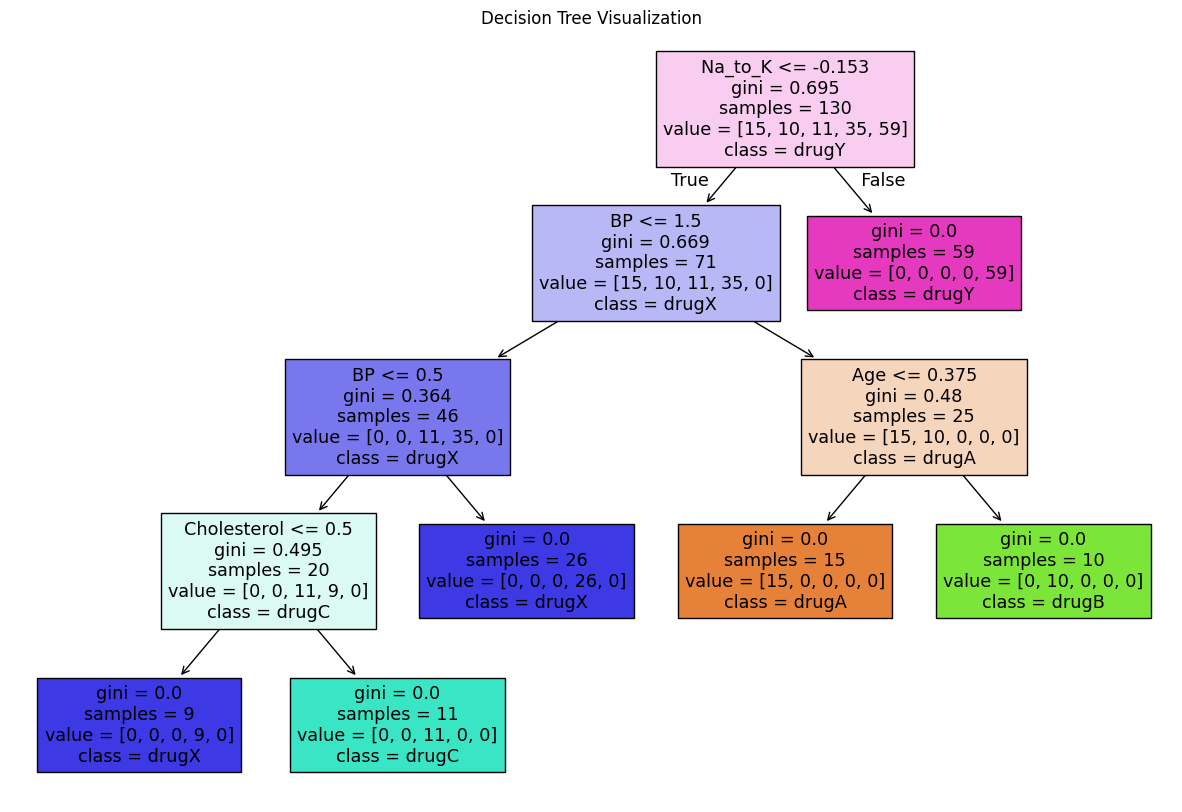

In [34]:
from sklearn.tree import plot_tree, DecisionTreeClassifier
import matplotlib.pyplot as plt
import graphviz
import sys

sys.setrecursionlimit(10000)

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

plt.figure(figsize=(15, 10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=label_encoder.classes_,
    filled=True
)
plt.title("Decision Tree Visualization")

decision_tree_rules = get_rules_iterative(dt_model, X_train.columns, label_encoder.classes_)

print("Decision Tree Model Rules:")
for rule in decision_tree_rules:
    print(rule)

plt.savefig("decision_tree_visualization.pdf")
plt.show()


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_train_pred = dt_model.predict(X_train)


y_test_pred = dt_model.predict(X_test)


print("Evaluation on Training Data:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Recall:", recall_score(y_train, y_train_pred, average='weighted'))
print("F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))


print("\nEvaluation Report on Training Data:")
print(classification_report(y_train, y_train_pred, target_names=label_encoder.classes_))


print("\nEvaluation on Testing Data:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


print("\nEvaluation Report on Testing Data:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))


Evaluation on Training Data:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
[[15  0  0  0  0]
 [ 0 10  0  0  0]
 [ 0  0 11  0  0]
 [ 0  0  0 35  0]
 [ 0  0  0  0 59]]

Evaluation Report on Training Data:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00        15
       drugB       1.00      1.00      1.00        10
       drugC       1.00      1.00      1.00        11
       drugX       1.00      1.00      1.00        35
       drugY       1.00      1.00      1.00        59

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130


Evaluation on Testing Data:
Accuracy: 0.9857142857142858
Precision: 0.9873015873015873
Recall: 0.9857142857142858
F1 Score: 0.985485103132162
Confusion Matrix:
[[ 8  0  0  0  0]
 [ 1  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 19  0]
 [ 0  0  0  0 32]]

Evaluation Report on Testing





> **Evaluation**





In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression(random_state=42)
logistic_regression_model.fit(X_train, y_train)


y_train_pred_lr = logistic_regression_model.predict(X_train)
y_test_pred_lr = logistic_regression_model.predict(X_test)


def evaluate_model(y_true, y_pred, model_name):
    print(f"\nEvaluation on {model_name} Data:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


evaluate_model(y_train, y_train_pred_lr, "Training (Logistic Regression)")
evaluate_model(y_test, y_test_pred_lr, "Testing (Logistic Regression)")


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
evaluate_model(y_train, y_train_pred_rf, "Training (Random Forest)")
evaluate_model(y_test, y_test_pred_rf, "Testing (Random Forest)")



xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)
evaluate_model(y_train, y_train_pred_xgb, "Training (XGBoost)")
evaluate_model(y_test, y_test_pred_xgb, "Testing (XGBoost)")


svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)
evaluate_model(y_train, y_train_pred_svm, "Training (SVM)")
evaluate_model(y_test, y_test_pred_svm, "Testing (SVM)")



Evaluation on Training (Logistic Regression) Data:
Accuracy: 0.9846153846153847
Precision: 0.9853146853146854
Recall: 0.9846153846153847
F1 Score: 0.9847427934384456
Confusion Matrix:
[[15  0  0  0  0]
 [ 0 10  0  0  0]
 [ 0  0 11  0  0]
 [ 0  0  0 34  1]
 [ 0  1  0  0 58]]

Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00        15
       drugB       0.91      1.00      0.95        10
       drugC       1.00      1.00      1.00        11
       drugX       1.00      0.97      0.99        35
       drugY       0.98      0.98      0.98        59

    accuracy                           0.98       130
   macro avg       0.98      0.99      0.98       130
weighted avg       0.99      0.98      0.98       130


Evaluation on Testing (Logistic Regression) Data:
Accuracy: 0.9142857142857143
Precision: 0.9274333193688032
Recall: 0.9142857142857143
F1 Score: 0.9163086287146438
Confusion Matrix:
[[ 8  0  0  0  0]
 [ 1  5  

In [31]:
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier

models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']

metrics_train = {
    'Model': models,
    'Accuracy': [
        accuracy_score(y_train, y_train_pred_lr),
        accuracy_score(y_train, y_train_pred_rf),
        accuracy_score(y_train, y_train_pred_xgb),
        accuracy_score(y_train, y_train_pred_svm)
    ],
    'Precision': [
        precision_score(y_train, y_train_pred_lr, average='weighted'),
        precision_score(y_train, y_train_pred_rf, average='weighted'),
        precision_score(y_train, y_train_pred_xgb, average='weighted'),
        precision_score(y_train, y_train_pred_svm, average='weighted')
    ],
    'Recall': [
        recall_score(y_train, y_train_pred_lr, average='weighted'),
        recall_score(y_train, y_train_pred_rf, average='weighted'),
        recall_score(y_train, y_train_pred_xgb, average='weighted'),
        recall_score(y_train, y_train_pred_svm, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_train, y_train_pred_lr, average='weighted'),
        f1_score(y_train, y_train_pred_rf, average='weighted'),
        f1_score(y_train, y_train_pred_xgb, average='weighted'),
        f1_score(y_train, y_train_pred_svm, average='weighted')
    ]
}

metrics_test = {
    'Model': models,
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_rf),
        accuracy_score(y_test, y_test_pred_xgb),
        accuracy_score(y_test, y_test_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_lr, average='weighted'),
        precision_score(y_test, y_test_pred_rf, average='weighted'),
        precision_score(y_test, y_test_pred_xgb, average='weighted'),
        precision_score(y_test, y_test_pred_svm, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_lr, average='weighted'),
        recall_score(y_test, y_test_pred_rf, average='weighted'),
        recall_score(y_test, y_test_pred_xgb, average='weighted'),
        recall_score(y_test, y_test_pred_svm, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_test_pred_lr, average='weighted'),
        f1_score(y_test, y_test_pred_rf, average='weighted'),
        f1_score(y_test, y_test_pred_xgb, average='weighted'),
        f1_score(y_test, y_test_pred_svm, average='weighted')
    ]
}


df_train_metrics = pd.DataFrame(metrics_train)
df_test_metrics = pd.DataFrame(metrics_test)

print("=== Training Metrics Comparison ===")
print(df_train_metrics)
print("\n=== Testing Metrics Comparison ===")
print(df_test_metrics)


=== Training Metrics Comparison ===
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.984615   0.985315  0.984615  0.984743
1        Random Forest  1.000000   1.000000  1.000000  1.000000
2              XGBoost  1.000000   1.000000  1.000000  1.000000
3                  SVM  1.000000   1.000000  1.000000  1.000000

=== Testing Metrics Comparison ===
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.914286   0.927433  0.914286  0.916309
1        Random Forest  0.985714   0.987302  0.985714  0.985485
2              XGBoost  0.942857   0.953322  0.942857  0.944138
3                  SVM  0.957143   0.961111  0.957143  0.957370


In [32]:
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

data = pd.read_csv("drug200.csv")

label_encoders = {}
for col in data.columns:
    if data[col].dtype == "object" and col != "Drug":
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

X = data.drop("Drug", axis=1)


y = data["Drug"]
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="linear", random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    if name == "XGBoost":
        scores = cross_val_score(model, X, y_encoded, cv=cv, scoring="accuracy")
    else:
        scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    results[name] = {
        "Scores": scores,
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std()
    }

for name, res in results.items():
    print(f"\n{name}")
    print("Scores:", res["Scores"])
    print("Mean Accuracy:", round(res["Mean Accuracy"], 3))
    print("Std Dev:", round(res["Std Dev"], 3))



Decision Tree
Scores: [1.    1.    1.    0.975 0.975]
Mean Accuracy: 0.99
Std Dev: 0.012

Random Forest
Scores: [1.    1.    1.    0.975 0.975]
Mean Accuracy: 0.99
Std Dev: 0.012

SVM
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
Std Dev: 0.0

XGBoost
Scores: [1.    0.975 0.95  0.95  0.95 ]
Mean Accuracy: 0.965
Std Dev: 0.02
